In [1]:
import numpy as np
from commercial_interrogator import BraggMeter
from matplotlib import pyplot as plt
from tensorflow.keras.models import load_model
from tensorflow.keras import backend as K
from _utils import find_bragg, find_wlres
from scipy.signal import savgol_filter
import pandas as pd
from scipy import stats
import warnings
import os
import logging

logger = logging.getLogger(__name__)

os.environ['TF_CPP_MIN_LOG_LEVEL']  = '2'
warnings.filterwarnings("ignore", category=UserWarning)

plt.rcParams['mathtext.fontset'] = 'cm' # dejavuserif
plt.rcParams['legend.framealpha'] = 1
plt.rcParams['legend.fontsize'] = 'small'
plt.rcParams['legend.title_fontsize'] = 'medium'
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman',
                              'DejaVu Serif',
                              'Bitstream Vera Serif',
                              'Computer Modern Roman',
                              'New Century Schoolbook',
                              'Century Schoolbook L',
                              'Utopia',
                              'ITC Bookman',
                              'Bookman',
                              'Nimbus Roman No9 L',
                              'Times',
                              'Palatino',
                              'Charter',
                              'serif']
plt.rcParams['xtick.labelsize'] = 'small'
plt.rcParams['ytick.labelsize'] = 'small'

# Preparing the model

In [2]:
# Load the model and the trained weights
model = load_model('./models/self_attention_2.keras', compile=False)
model.load_weights('./models/self_attention_weights_2.h5')
f_model = K.function(model.input,
                     model.output)

# FBG designed Bragg wavelength and its spacing
base_position = np.linspace(1510, 1590, 13)
d_bragg = np.mean(np.diff(base_position))

In [3]:
def predict_with_uncertainty(f, x, n_iter=100):
    """
    This function predicts the output of a model with uncertainty.

    Parameters:
    f (function): The model function.
    x (array-like): The input data to the model.
    n_iter (int, optional): The number of iterations for uncertainty estimation. Defaults to 100.

    Returns:
    tuple: The predicted output and its uncertainty.
    """
    # Set the learning phase to 1 (training mode)
    K.set_learning_phase(1)
    # Initialize an array to store the results of each iteration
    result = np.zeros((n_iter, x[0].shape[0], 1))
    # Run the model function for each iteration and store the results
    for i in range(n_iter):
        result[i] = f(x)
    # Calculate the mean prediction across all iterations
    prediction = result.mean(axis=0)
    # Calculate the uncertainty of the prediction using the t-distribution
    uncertainty = stats.t.ppf(0.975, n_iter - 1) * result.std(axis=0)/np.sqrt(n_iter)
    # Set the learning phase back to 0 (test mode)
    K.set_learning_phase(0)
    # Return the prediction and its uncertainty
    return prediction.flatten(), uncertainty.flatten()

# Using an OSA

In [4]:
osa_measurements = pd.read_csv('./data/WaveData20240328_004.csv', skiprows=190)

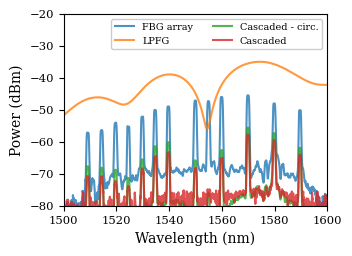

In [5]:
plt.figure(figsize=(3.4, 2.5))

traces = {}
trace_name = {'A': 'FBG array', 'B': 'LPFG', 'C': 'Cascaded - circ.', 'E': 'Cascaded'}
for letter in ['A', 'B', 'C', 'E']:
    spec = osa_measurements[[f'Wavelength({letter})', f'Level({letter})']].values
    spec[:, 1] = 10*np.log10(np.abs(spec[:, 1]))
    spec[:, 1] = savgol_filter(spec[:, 1], 11, 3)
    traces[letter] = spec

    plt.plot(spec[:, 0], spec[:, 1], label=trace_name[letter], alpha=0.8)
plt.legend(fontsize=7, ncols=2, loc='upper right')
plt.xlabel('Wavelength (nm)')
plt.ylabel('Power (dBm)')
plt.xlim(1500, 1600)
plt.ylim(-80, -20)
plt.show()

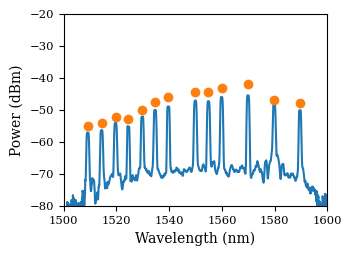

In [6]:
ref_wl, ref_intensity = find_bragg(traces['A'][:,0], traces['A'][:,1], dwl=6, prominence=10)
plt.figure(figsize=(3.4, 2.5))
plt.plot(traces['A'][:,0], traces['A'][:,1], label='Measured')
plt.plot(ref_wl, ref_intensity, 'o', label='Detected Bragg peak')
plt.xlabel('Wavelength (nm)')
plt.ylabel('Power (dBm)')
plt.xlim(1500, 1600)
plt.ylim(-80, -20)
plt.show()

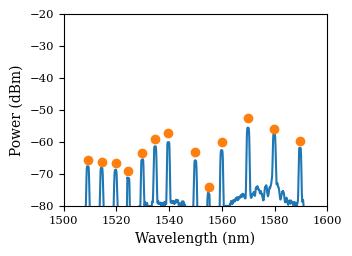

In [7]:
wl, intensity = find_bragg(traces['C'][:,0], traces['C'][:,1], dwl=6, prominence=10)
plt.figure(figsize=(3.4, 2.5))
plt.plot(traces['C'][:,0], traces['C'][:,1], label='Measured')
plt.plot(wl, intensity, 'o', label='Detected Bragg peak')
plt.xlabel('Wavelength (nm)')
plt.ylabel('Power (dBm)')
plt.xlim(1500, 1600)
plt.ylim(-80, -20)
plt.show()

In [8]:
target = find_wlres(1e-9*traces['B'][:, 0], traces['B'][:, 1])

x = intensity - ref_intensity
x = x/np.sum(x)
x -= min(x)
x = x/np.sum(x)

x_fbgs = (wl - base_position)/d_bragg

In [9]:
pred, u = predict_with_uncertainty(f_model, [x.reshape(1, -1), x_fbgs.reshape(1, -1)])

In [13]:
pred, u

(array([1554.55338745]), array([0.48976397]))

In [12]:
target

1554.4193

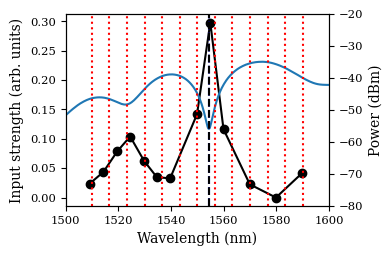

In [10]:
## ESSE ARRAY ESTÁ MUITO LONGE DO DE PROJETO, RETREINAR O MODELO PARA SUPORTAR ARRAY MAIS "ERRADO"

plt.figure(figsize=(3.4, 2.5))
plt.plot(wl, x, '-ok', label='SA-FCC input')
plt.xlabel('Wavelength (nm)')
plt.ylabel('Input strength (arb. units)')
plt.twinx()
plt.plot(traces['B'][:,0], traces['B'][:,1], label='LPFG')
plt.ylabel('Power (dBm)')
plt.vlines(base_position, -80, -20, 'r', ':', label='FBG Bragg wavelengths')
plt.vlines(target, -80, -20, 'b', '--', label='Target')
plt.vlines(pred, -80, -20, 'k', '--', label='Predicted')
plt.xlim(1500, 1600)
plt.ylim(-80, -20)
plt.show()

# Getting the FBG array properties

Get the peak intensity and position for each FBG, for the FBG array alone (without LPFG). Saves for future source compensation.

## Measure only the FBG array

In [6]:
# Object to control the FBG interrogato
my_osa = BraggMeter()

my_osa.set_gain(0, 255)

KeyboardInterrupt: 

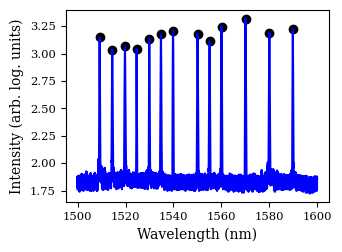

In [ ]:
# Start measurement
my_osa.start()
# Get the measurements (intensity and Bragg wavelength) @ channel 0
intensity = my_osa.get_peaks(0)
intensity = np.log10(intensity)
bragg = my_osa.get_bragg(0)
spec = my_osa.get_osa_trace(0)
spec[:,1] = 10*np.log10(spec[:,1])
# Finish measurement
my_osa.stop()
# Show the results
plt.figure(figsize=(3.4, 2.5))
plt.plot(bragg, intensity, 'ok')
plt.xlabel('Wavelength (nm)')
plt.ylabel('Intensity (arb. log. units)')
plt.plot(spec[:,0], spec[:,1], 'b')
plt.show()
reference_intensity = intensity.copy()
reference_spec = spec.copy()

# Measurring with a cascaded LPFG

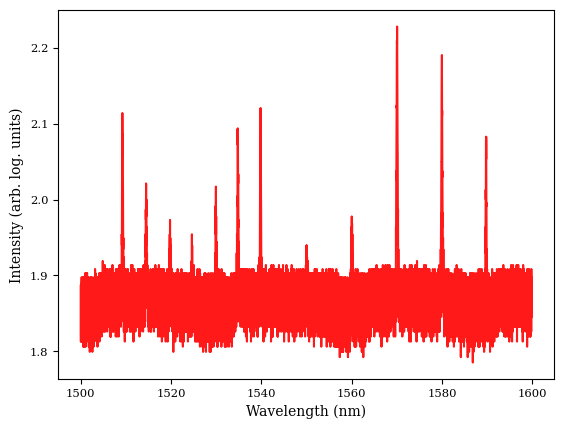

In [ ]:
# Start measurement
my_osa.start()
# Get the measurements (intensity and Bragg wavelength) @ channel 0
intensity = my_osa.get_peaks(0)
intensity = 10*np.log10(intensity)
bragg = my_osa.get_bragg(0)
spec = my_osa.get_osa_trace(0)
spec[:,1] = np.log10(spec[:,1])
# Finish measurement
my_osa.stop()
# Show the results
plt.figure(figsize=(3.4, 2.5))
plt.plot(bragg, intensity, 'ok')
plt.xlabel('Wavelength (nm)')
plt.ylabel('Intensity (arb. log. units)')
plt.plot(spec[:,0], spec[:,1], 'r', alpha=0.9)
plt.show()

In [ ]:
to_save = {'ref': reference_spec, 'spec': spec}
with open('./data/bragg_meter_1.pkl', 'wb') as f:
    np.save(f, to_save)

# Performing the LPFG interrogation/demodulation

In [40]:
with open('./data/bragg_meter_1.pkl', 'rb') as f:
    loaded_data = np.load(f, allow_pickle=True).item()

ref = loaded_data['ref']
spec = loaded_data['spec']

ref[:,1] = savgol_filter(ref[:,1], 11, 2)
spec[:,1] = savgol_filter(spec[:,1], 11, 2)


In [38]:
ref_wl, ref_intensity = find_bragg(ref[:,0], ref[:,1], dwl=6, prominence=3)
sort = ref_wl.argsort()
ref_wl = ref_wl[sort]
ref_intensity = ref_intensity[sort]

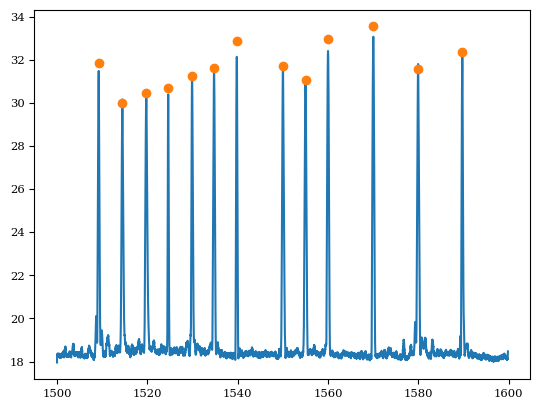

In [39]:
plt.plot(ref[:,0], ref[:,1])
plt.plot(ref_wl, ref_intensity, 'o')

In [49]:
wl_bragg, intensity = find_bragg(spec[:,0], spec[:,1], dwl=6, prominence=0.5)
sort = wl_bragg.argsort()
wl_bragg = wl_bragg[sort]
intensity = intensity[sort]

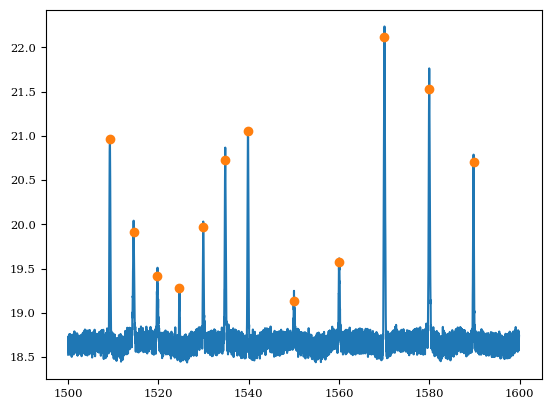

In [50]:
plt.plot(spec[:,0], spec[:,1])
plt.plot(wl_bragg, intensity, 'o')

In [52]:
wl_bragg

array([1509.25170257, 1514.49780746, 1519.78331535, 1524.65605873,
       1529.94026286, 1534.80526219, 1539.83412109, 1550.04934813,
       1560.04589088, 1570.06246136, 1579.98813878, 1589.78100874])

In [54]:
ref_wl

array([1509.24420601, 1514.48836842, 1519.78634246, 1524.63876053,
       1529.94353422, 1534.79229696, 1539.82214911, 1550.05915466,
       1555.04770269, 1560.0380592 , 1570.05840244, 1579.99145551,
       1589.76966658])

In [73]:
corrected_wl  = []
corrected_int = []
for fbg in ref_wl:
    detected = np.abs(fbg - wl_bragg) < d_bragg/2
    if sum(detected) == 0:
        print(f'missing fbg: {fbg}, too close do LPFG dip')
        corrected_wl.append(fbg)
        corrected_int.append(min(intensity))
    else:
        corrected_wl.append(wl_bragg[detected][0])
        corrected_int.append(intensity[detected][0])
corrected_wl = np.array(corrected_wl)
corrected_int = np.array(corrected_int)

missing fbg: 1555.047702694621, too close do LPFG dip


In [83]:
x = corrected_int - ref_intensity
x = x/np.sum(x)
x = x-min(x)
x = x/np.sum(x)


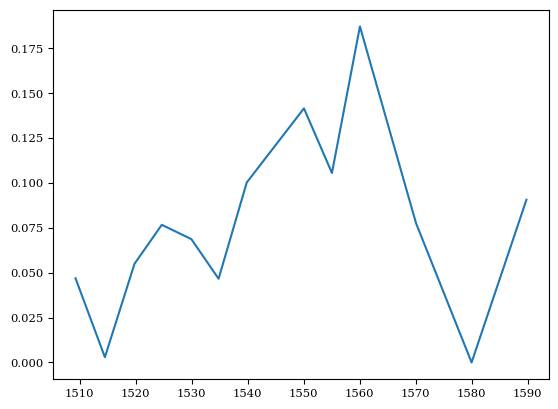

In [84]:
plt.plot(corrected_wl, x)